# Segmentation des agences BTK (apprentissage non supervisé)

Segmentation du réseau à partir du datamart produit par la chaîne ETL.

> **Exécution : menu *Kernel → Restart Kernel and Run All Cells*.**
> La première cellule (« 0. Préparation ») définit les imports et le chemin du
> projet : elle doit passer en premier.

**Prérequis :** exécuter d'abord `etl/etl_btk.ipynb` (ou
`python3 etl/etl_agences.py`), qui écrit `clustering/data/agences.csv`.
À défaut, ce notebook repart de l'extrait réel livré avec le projet.

## 0. Préparation

In [1]:
import os, sys
import numpy as np
import pandas as pd

# On remonte depuis le dossier courant jusqu'à celui qui contient à la fois
# les répertoires "etl" et "clustering" : c'est la racine du projet.
_dossier = os.path.abspath(os.getcwd())
while not all(os.path.isdir(os.path.join(_dossier, d)) for d in ("etl", "clustering")):
    _parent = os.path.dirname(_dossier)
    if _parent == _dossier:
        raise FileNotFoundError(
            "Racine du projet introuvable depuis " + os.getcwd() + "\n"
            "Placez ce notebook dans le dossier du projet, à côté des dossiers "
            "« etl » et « clustering », puis relancez cette cellule.")
    _dossier = _parent
RACINE = _dossier

pd.set_option("display.width", 170, "display.max_columns", 20)
print("Racine du projet :", RACINE)
print("pandas", pd.__version__, "| numpy", np.__version__)

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
import sklearn

print("scikit-learn", sklearn.__version__, "| matplotlib", plt.matplotlib.__version__)

NAVY, CYAN, ORANGE, GREEN = "#14507A", "#1B9CD8", "#E8A33D", "#2E9E6B"
FEATURES = ["effectif", "nb_gestionnaires", "nb_clients",
            "total_comptes", "production_credits", "collecte_epargne"]

Racine du projet : /home/user/oussema_korbosli
pandas 3.0.5 | numpy 2.4.6


scikit-learn 1.9.0 | matplotlib 3.11.1


## 1. Chargement du datamart

In [2]:
if "RACINE" not in globals():
    raise RuntimeError("Exécutez d'abord la cellule « 0. Préparation ». "
                       "Le plus simple : menu Kernel > Restart Kernel and Run All Cells.")

DATA = os.path.join(RACINE, "clustering", "data")
src = os.path.join(DATA, "agences.csv")
if not os.path.exists(src):
    src = os.path.join(DATA, "agences_reelles.csv")
brut = pd.read_csv(src)
print("datamart :", os.path.relpath(src, RACINE), "|", len(brut), "entités")
brut.head()

datamart : clustering/data/agences.csv | 49 entités


,agence,effectif,nb_gestionnaires,nb_clients,total_comptes,production_credits,collecte_epargne
0,BIZERTE,10,8,1795,799,6300000,812500
1,MGHIRA,9,6,1791,607,5880000,690000
2,MONASTIR,12,10,1497,557,7000000,450000
3,GROMBALIA,12,6,1451,618,5400000,662500
4,BEN AROUS,18,7,1313,708,8300000,720000


## 2. Préparation des variables

Le **siège** (540 employés) est une structure centrale, pas une agence : il est
conservé dans le datamart mais écarté de la segmentation, où il constitue un
point atypique qui écraserait toute autre structure.

Le portefeuille et les montants sont très asymétriques : ils passent au
**logarithme** avant standardisation, afin qu'une agence extrême ne domine pas
les distances.

In [3]:
df = brut[brut["agence"] != "SIEGE"].reset_index(drop=True)
T = df[FEATURES].copy()
for c in ["nb_clients", "total_comptes", "production_credits", "collecte_epargne"]:
    T[c] = np.log1p(T[c])
X = StandardScaler().fit_transform(T)
print(f"{len(brut)} entités, {len(df)} retenues (siège écarté) x {len(FEATURES)} indicateurs")
print("matrice standardisée :", X.shape)

49 entités, 48 retenues (siège écarté) x 6 indicateurs
matrice standardisée : (48, 6)


## 3. Choix du nombre de clusters

Méthode du coude (inertie intra-cluster) et score de silhouette.
`k = 2` isolerait trivialement les entités sans activité : on retient la
meilleure solution à partir de `k = 3`, exploitable pour le pilotage.

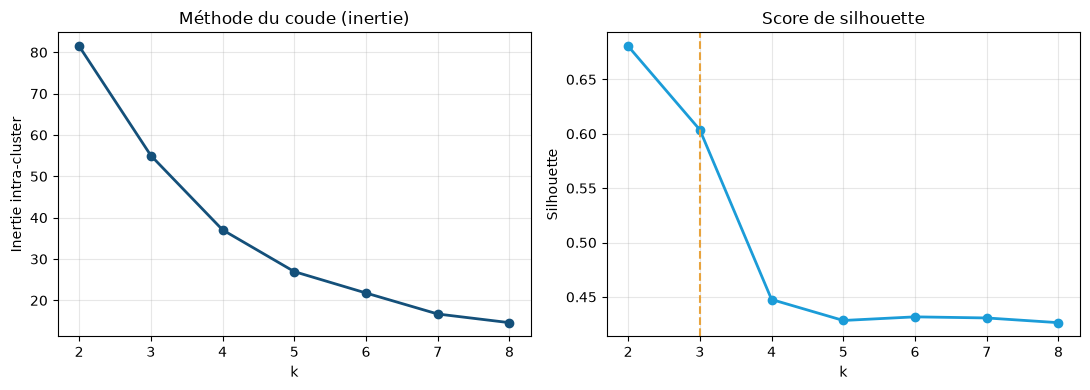

silhouettes : [0.681, 0.604, 0.448, 0.428, 0.432, 0.431, 0.426] -> k optimal = 3


In [4]:
ks = range(2, 9)
inerties, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inerties.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))
k_opt = list(ks)[int(np.argmax([s if k >= 3 else -1 for k, s in zip(ks, sils)]))]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inerties, "o-", color=NAVY, lw=2)
ax[0].set_title("Méthode du coude (inertie)"); ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertie intra-cluster"); ax[0].grid(alpha=.3)
ax[1].plot(list(ks), sils, "o-", color=CYAN, lw=2)
ax[1].axvline(k_opt, ls="--", color=ORANGE)
ax[1].set_title("Score de silhouette"); ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print("silhouettes :", [round(s, 3) for s in sils], "-> k optimal =", k_opt)

## 4. Comparaison des modèles

Quatre modèles sont comparés. **Protocole d'évaluation équitable :** chaque
modèle est noté sur *la totalité* des agences ; les points qu'un modèle refuse
de classer (bruit DBSCAN) sont comptés comme un groupe à part entière, pour
qu'aucun modèle ne soit avantagé par le fait d'avoir écarté les agences les plus
difficiles à classer.

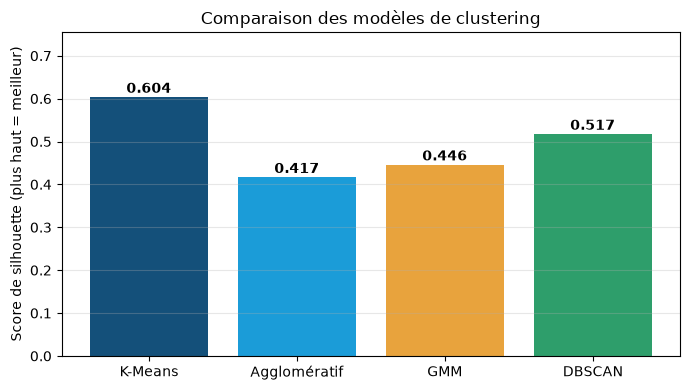

,Modèle,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,0.604,0.709,95.243
1,Agglomératif,3,0.417,0.841,90.846
2,GMM,3,0.446,0.770,89.056
3,DBSCAN,4,0.517,0.393,65.381


In [5]:
modeles = {
    "K-Means": KMeans(n_clusters=k_opt, n_init=10, random_state=42).fit_predict(X),
    "Agglomératif": AgglomerativeClustering(n_clusters=k_opt).fit_predict(X),
    "GMM": GaussianMixture(n_components=k_opt, random_state=42).fit_predict(X),
    "DBSCAN": DBSCAN(eps=1.5, min_samples=3).fit_predict(X),
}
lignes = []
for nom, lab in modeles.items():
    lab = lab.copy()
    if (lab == -1).any():
        lab[lab == -1] = lab.max() + 1
    lignes.append([nom, len(set(lab)), silhouette_score(X, lab),
                   davies_bouldin_score(X, lab), calinski_harabasz_score(X, lab)])
comp = pd.DataFrame(lignes, columns=["Modèle", "Clusters", "Silhouette",
                                     "Davies-Bouldin", "Calinski-Harabasz"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comp["Modèle"], comp["Silhouette"], color=[NAVY, CYAN, ORANGE, GREEN])
for i, v in enumerate(comp["Silhouette"]):
    ax.text(i, v + .01, f"{v:.3f}", ha="center", fontsize=10, weight="bold")
ax.set_ylabel("Score de silhouette (plus haut = meilleur)")
ax.set_title("Comparaison des modèles de clustering")
ax.set_ylim(0, comp["Silhouette"].max() * 1.25); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()
comp.round(3)

## 5. Modèle retenu et projection

Le modèle retenu est celui qui obtient le meilleur score de silhouette sous le
protocole ci-dessus. La projection **ACP** ramène les six indicateurs à deux
composantes pour visualiser les groupes.

modèle retenu : K-Means


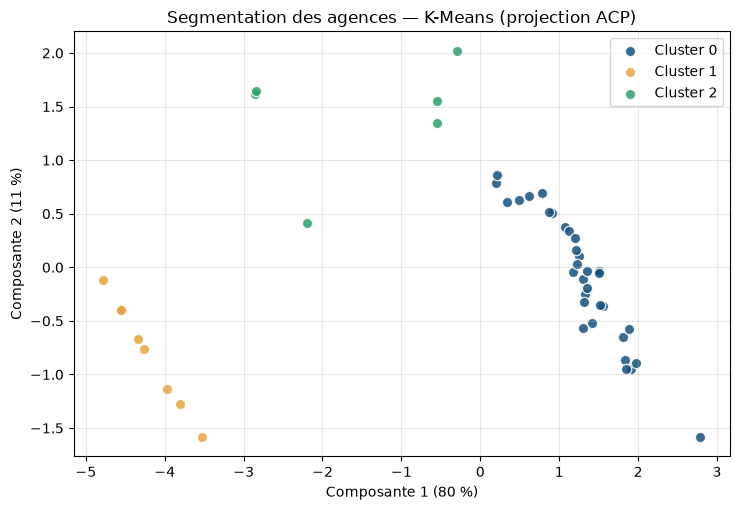

In [6]:
best = comp.loc[comp["Silhouette"].idxmax(), "Modèle"]
labels = modeles[best]
print("modèle retenu :", best)

p = PCA(n_components=2).fit(X); Z = p.transform(X)
fig, ax = plt.subplots(figsize=(7.5, 5.2))
cols = [NAVY, ORANGE, GREEN, CYAN, "#B0489B"]
for c in sorted(set(labels)):
    m = labels == c
    ax.scatter(Z[m, 0], Z[m, 1], s=55, alpha=.85, color=cols[c % len(cols)],
               label=f"Cluster {c}", edgecolor="white")
ax.set_xlabel(f"Composante 1 ({p.explained_variance_ratio_[0]*100:.0f} %)")
ax.set_ylabel(f"Composante 2 ({p.explained_variance_ratio_[1]*100:.0f} %)")
ax.set_title(f"Segmentation des agences — {best} (projection ACP)")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Profils des segments

In [7]:
d = df.copy(); d["cluster"] = labels
prof = d.groupby("cluster")[FEATURES].mean().round(0).astype(int)
prof["nb_agences"] = d.groupby("cluster").size()
prof = prof[["nb_agences"] + FEATURES]
for c in sorted(set(labels)):
    noms = d.loc[d.cluster == c, "agence"].tolist()
    print(f"Cluster {c} ({len(noms)}) : {', '.join(noms[:8])}{' …' if len(noms) > 8 else ''}")
prof

Cluster 0 (34) : BIZERTE, MGHIRA, MONASTIR, GROMBALIA, BEN AROUS, CENTRALE, NABEUL, SFAX 2 …
Cluster 1 (8) : AGBA, Menzah 6, Agence Internationale, Agence Premium Siège, Agence Premium Tunis Sud, SFAX 5, Zaghouan Hammam Zriba, INTERNATIONAL
Cluster 2 (6) : LAC 2, SOUSSE 3, MAHDIA, Agence Régionale Tunis Sud, Agence Régionale Tunis Nord, HAMMAMET


,nb_agences,effectif,nb_gestionnaires,nb_clients,total_comptes,production_credits,collecte_epargne
cluster,,,,,,,
0,34,12,7,880,559,7800603,553088
1,8,3,2,0,0,0,0
2,6,4,3,2,285,14611382,747171


## 7. Vérification

Le notebook doit retrouver **exactement** le résultat du script
`clustering/segmentation_reelle.py`.

In [8]:
import subprocess

script = os.path.join(RACINE, "clustering", "segmentation_reelle.py")
if not os.path.exists(script):
    print("Script clustering/segmentation_reelle.py absent : vérification ignorée.")
else:
    r = subprocess.run([sys.executable, script], cwd=RACINE,
                       capture_output=True, text=True)
    if r.returncode:
        print(r.stderr[-800:])
        raise RuntimeError("Le script s'est terminé en erreur.")
    ref = pd.read_csv(os.path.join(RACINE, "clustering",
                                   "comparaison_modeles_reelles.csv"))
    ecart = float(np.abs(ref["Silhouette"].values - comp["Silhouette"].values).max())
    print("écart maximal sur la silhouette entre notebook et script :", round(ecart, 12))
    assert ecart < 1e-9, "Écart entre le notebook et le script."
    print("Résultats identiques.")

écart maximal sur la silhouette entre notebook et script : 0.0
Résultats identiques.
